# Kanapy – Voxelized RVE and anisotropic power diagram
Generate a representatative volume element (RVE) for a synthetic microstructure and export geometry as Abaqus INP file. Generate orientation for each grain in form of Euler angles that are characteristic for a given crystallographic texture.

The continuous APD alternative in sections 2.3a–2.3e branches directly from the ellipsoid packing.


Author: Alexander Hartmaier, ICAMS / Ruhr-University Bochum, Germany<br>
Copyright &copy; by the author, August 2025

### 1. Import required libraries

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import kanapy as knpy
from kanapy.core.voxelization import nonmanifold_grain_boundary_voxels
print(f'Kanapy version {knpy.__version__}')

Kanapy version 6.5.5


Creating an RVE based on user defined statistics
    Analyzed statistical data for phase Austenite_fcc (0)
    Total number of particles  = 11
  RVE characteristics:
    RVE side lengths (X, Y, Z) = (15, 15, 15) (um)
    Number of voxels (X, Y, Z) = (24, 24, 24)
    Voxel resolution (X, Y, Z) = [0.625 0.625 0.625](um)
    Total number of voxels     = 13824


Considered phases (volume fraction): 
0: Austenite_fcc (100.0%)


Starting particle simulation
    Creating particles from distribution statistics
    Total volume of generated ellipsoids: 3367.144350596067
    Particle packing by growth simulation
Volume of simulation box: 3375
Volume of unscaled particles: 3367.1443505960674
Initial volume of scaled ellipsoids: 3.3671443505960696, targeted final volume: 1346.8577402384271
Volume increment per time step: 3.3671443505960674


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 646/646 [00:01<00:00, 608.60it/s]


Actual final volume of ellipsoids: 1343.6618873033644
Final relaxation: 500 steps, 11 -> 13 overlapping image contacts (step_limit)
Completed particle packing
13 overlapping particles detected after packing
Kinetic energy of particles after packing: 0.0



/opt/miniconda3/envs/knpy/lib/python3.13/site-packages/kanapy/core/packing.py:324: RuntimeWarning: Packing relaxation did not converge: step_limit; 13 overlapping image contacts remain.
  Ellipsoids, sim_box.packing_relaxation = relax_particles(


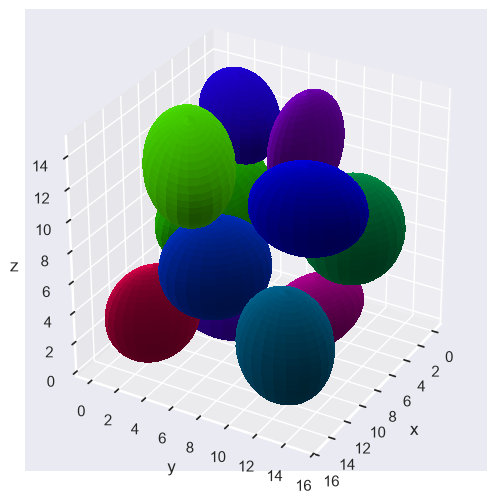

    Generating voxels inside RVE


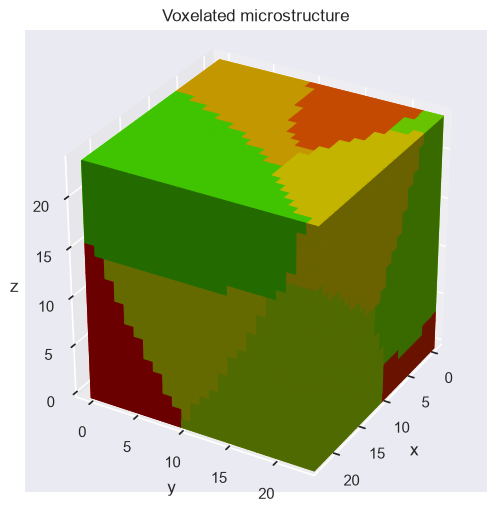

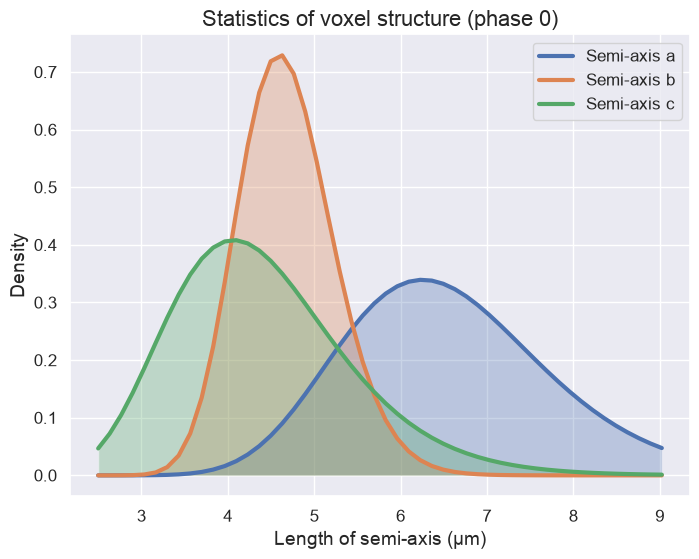


Statistical microstructure parameters of RVE
--------------------------------------------
Type	| a (µm) 	| b (µm) 	| c (µm) 	| std.dev	| rot.axis	| asp.ratio	| std.dev	| equ.dia. (µm)	| std.dev
Input	|  -      	|  -      	|  -      	|   -      	|     -   	|  1.500	|  0.8000	|     9.000 	|  0.4000
Output	|  6.473	|  4.659	|  4.295	|  0.1788	|     0   	|  1.446	|  0.0756	|     8.783 	|  0.0984


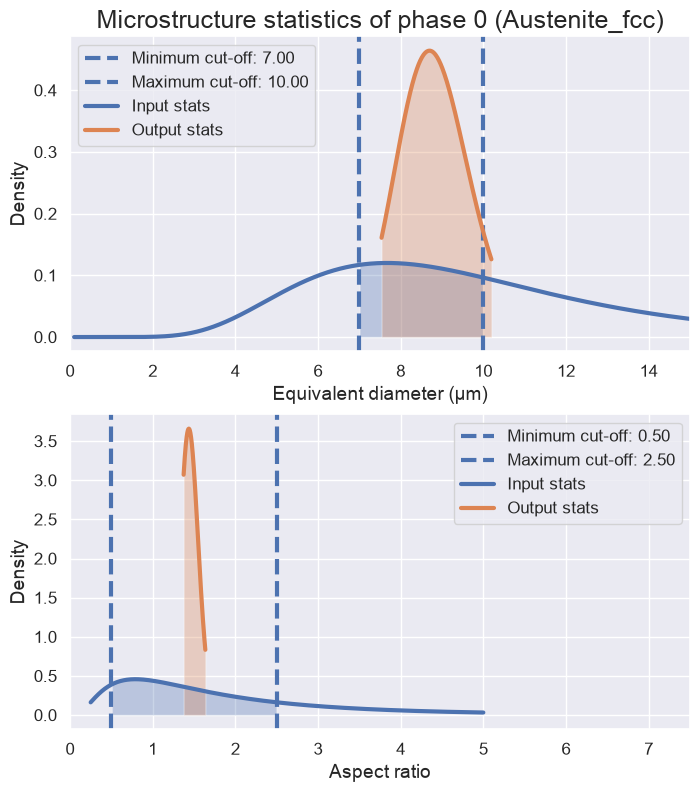

In [10]:
# Basic definitions
matname = 'Austenite_fcc'
matnumber = 3
deg = np.pi/180.0

# RVE and microstructure parameters
Nv = 24  # number of voxels along each Cartesian direction
size = 15  # size of RVE in micron
periodic = False  # periodicity of microstructure
ms_elong = {'Grain type': 'Elongated',
          'Equivalent diameter': {'sig': 0.4, 'scale': 9.0, 'cutoff_min': 7.0, 'cutoff_max': 10.0},
          'Aspect ratio': {'sig':0.8, 'scale': 1.5, 'cutoff_min': 0.5, 'cutoff_max': 2.5},
          #'Aspect ratio': {'sig':0.6, 'scale': 4.5, 'cutoff_min': 2.5, 'cutoff_max': 7.5},
          'Tilt angle': {'kappa': 0.8, 'loc': 90.*deg, "cutoff_min": 0.0*deg, "cutoff_max": 180.0*deg},
          #'Tilt angle': {'kappa': 0.6, 'loc': 90.*deg, "cutoff_min": 50.0*deg, "cutoff_max": 130.0*deg},
          'RVE': {'sideX': size, 'sideY':size, 'sideZ': size, 'Nx': Nv, 'Ny': Nv, 'Nz': Nv, 'ialloy': matnumber},
          'Simulation': {'periodicity': periodic, 'output_units': 'um'},
          'Phase': {'Name': matname, 'Number': 0, 'Volume fraction': 1.0}}

# Seed particle sampling and initial placement.
import random
np.random.seed(42)
random.seed(42)
ms = knpy.Microstructure(descriptor=ms_elong, name=matname)
#ms.plot_stats_init()  # plot initial statistics of equivalent grain diameter and aspect ratio
ms.init_RVE()  # initialize RVE including particle distribution

# Create RVE
ms.pack(fill_factor=0.4, relaxation_steps=500)  # perform particle simulation to distribute grain nuclei in RVE volume
ms.plot_ellipsoids()  # plot final configuration of particles
#print(ms.simbox.packing_relaxation)
ms.voxelize() #dim=(50, 50, 50))  # create structured mesh and assign voxels to grains according to particles
ms.plot_voxels(sliced=False)  # plot voxels colored according to grain number
ms.plot_stats_init(show_res=True, get_res=True) # compare final grain statistics with initial parameters

Number of voxels in non-manifold configurations: 20


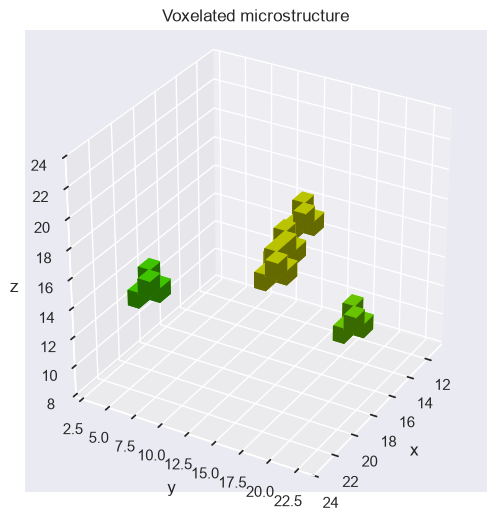

In [14]:
mask = nonmanifold_grain_boundary_voxels(
    ms.mesh.grains, periodic=ms.rve.periodic
)
voxel_ids = np.flatnonzero(mask) + 1
print(f'Number of voxels in non-manifold configurations: {len(voxel_ids)}')

# plot voxels at grain boundaries
knpy.plot_voxels_3D(ms.mesh.grains, mask=mask)

In [12]:
report = ms.anneal(volume_change=0.2)
print(report["reason"], report["max_volume_change"])

volume_change 0.20112994350282487


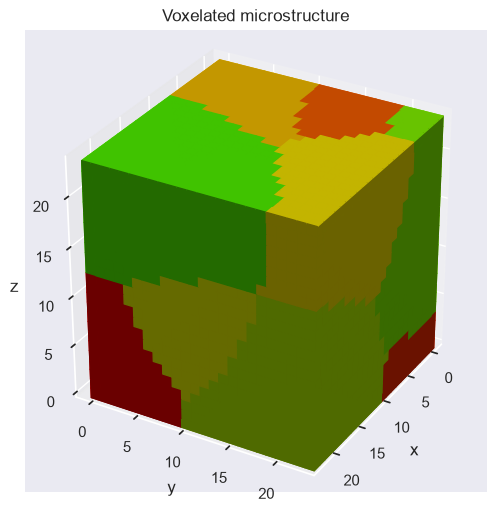

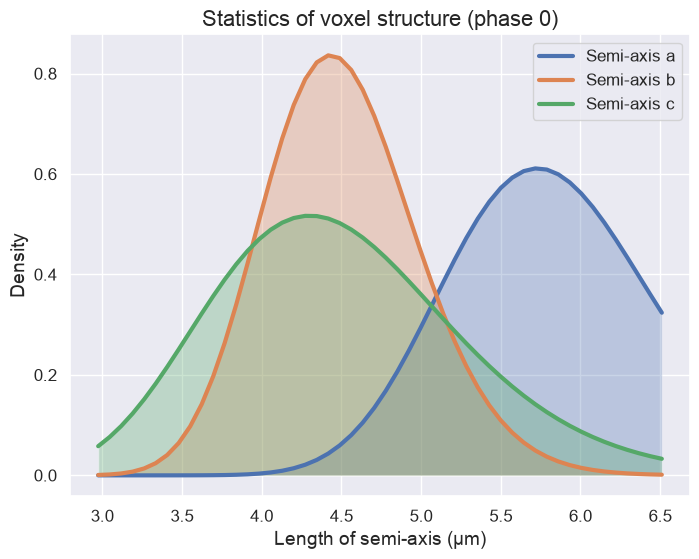


Statistical microstructure parameters of RVE
--------------------------------------------
Type	| a (µm) 	| b (µm) 	| c (µm) 	| std.dev	| rot.axis	| asp.ratio	| std.dev	| equ.dia. (µm)	| std.dev
Input	|  -      	|  -      	|  -      	|   -      	|     -   	|  1.500	|  0.8000	|     9.000 	|  0.4000
Output	|  5.804	|  4.484	|  4.439	|  0.1322	|     0   	|  1.301	|  0.0495	|     8.888 	|  0.1183


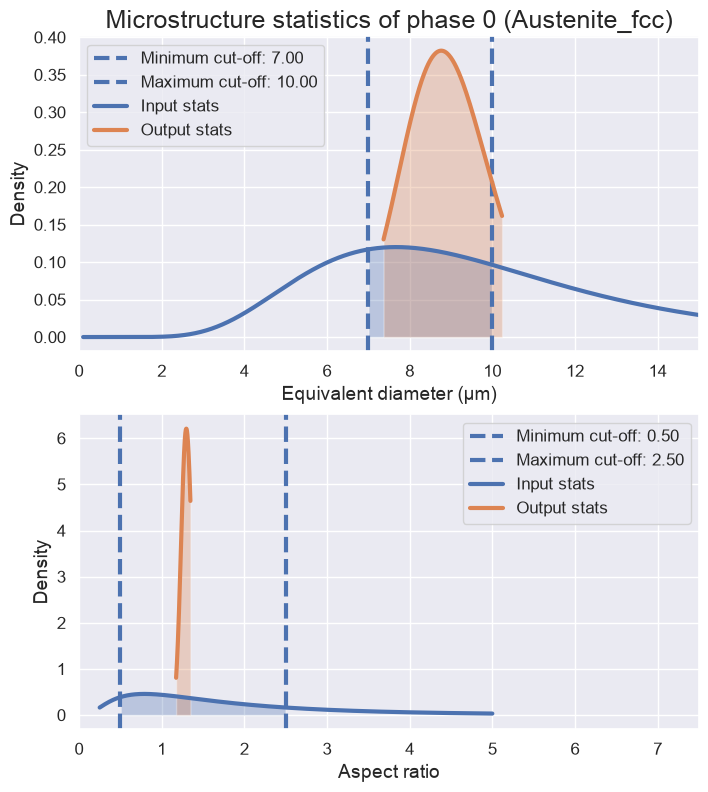

In [13]:
ms.plot_voxels(sliced=False)
ms.plot_stats_init(show_res=True, get_res=True)

In [6]:
ms.anneal?

Signature: ms.anneal(*, periodic=None, **options)
Docstring:
Anneal a single-phase voxel mesh using optional FiPy grain growth.

Defaults: dimensionless mobility=10, kappa=2, dt=0.002,
max_steps=2000, volume_change=0.1. Stop when ANY grain changes
volume by at least 10% relative to its volume at this call's start.
The first crossing is retained; voxel quantization can overshoot.
Return diagnostics including reason, steps and initial/final volumes.
Periodicity defaults to the voxelization APD or RVE setting.
This changes voxel labels; APD geometry is invalidated. Use smoothen()
for the annealed boundaries, not generate_grains().
File:      /opt/miniconda3/envs/knpy/lib/python3.13/site-packages/kanapy/core/api.py
Type:      method

In [ ]:
octree = ms.mesh.apd.background_octree(
    resolution=2,   # initial cells per axis
    max_depth=4,    # maximum number of subdivisions
    max_cells=1_000_000,
)

print(octree.summary())
octree.plot_slice(axis='z', color_by='level')
octree.plot_slice(axis='z', color_by='grain')
octree.plot_slice(axis='z', color_by='boundary')
plt.show()

In [ ]:
thin = octree.thin_grain_cells(max_width=2)
report = octree.clean_thin_grains(ms.mesh.apd, max_width=2)

print(report['changed_cells'])
print(report['remaining_thin_cells'])
octree.plot_slice(color_by='grain')

mask = octree.nonmanifold_grain_boundary_cells()

report = octree.nonmanifold_grain_boundary_cells(return_report=True)
print(report['nonmanifold_cells'])
print(report['contacts'])

octree.plot_slice(axis='z', color_by='nonmanifold')

In [ ]:
print(octree.summary())
octree.plot_slice(axis='z', color_by='level')
octree.plot_slice(axis='z', color_by='grain')
octree.plot_slice(axis='z', color_by='boundary')
plt.show()

In [ ]:

ms.generate_grains(
    resolution=20,
    periodic_images=False,
)
ms.plot_grains()
result = ms.remesh_grains(mesh_size=2.0)
ms.write_stl("remeshed.stl", boundary=result.surface, include_exterior=True)

ms.plot_grains()  # uses the stored periodic whole-grain view


### Diagnose residual clusters on the current packing

Run the following cell manually after the growth error above. It reuses **the existing `ms.particles`**, without repacking or modifying `ms`, and captures the unassigned tetrahedra just before cluster fallback. This is important because a fresh packing can differ despite the random seeds.

Saturated colours mark individual face-connected residual clusters (including connections across periodic box faces); pale colours mark the five original grains. The sections intersect the actual tetrahedra. Cluster IDs, sizes, locations and eventual owners are written to `analysis/work_clusters/clusters.csv`. Image IDs in surface errors are separate from original grain IDs.


### 2.3a. Continuous anisotropic power diagram (alternative to voxelization)

This branch uses **only `ms.particles` and the simulation box** after packing.
It does not call `voxelize()` or change the `ms` object. Run through section
2.3e to inspect this result; the original voxel workflow continues in section 2.4.

For each original ellipsoid we construct a positive-definite shape matrix with
unit determinant. The grain is the region where
\[
q_i(x)=(x-c_i)^T A_i(x-c_i)-w_i
\]
is smallest. Kanapy's row-vector rotation convention is retained. Periodic images
share the same weight and grain ID, and the grain cost is minimized over lattice
images. Stored duplicate particles are excluded from the target volumes.

Weights are fitted to ellipsoid volume **ratios**, rescaled to fill the RVE.
The fit uses Sobol quadrature points, not a voxel mesh. It controls sampled grain
volumes; final aspect ratios and grain connectivity are **not guaranteed**.
The matrices encode morphological orientation, not crystal orientation.

Reference: [Buze et al. (2024), Anisotropic power diagrams for polycrystal modelling](https://doi.org/10.1016/j.commatsci.2024.113317).

In [ ]:
fit = ms.mesh.apd.fit_volumes(n_samples=2**16, seed=0, tolerance=0.03)
print(f"{len(ms.mesh.apd.centers)} original grains; periodic={ms.mesh.apd.periodic}")
print(f"Sampled volume tolerance reached: {fit['converged']}")
print(f"Maximum training volume error: {fit['max_relative_error']:.2%}")
print(f"Optimizer: {fit['message']}")

### 2.3b. Independent volume check and sections

The following estimate uses a different Sobol sample from the fit. Its error can
exceed the training error, especially for small grains. Increase both sample
counts to check quadrature convergence. The scatter plot compares grain volumes;
the colored sections evaluate the continuous APD directly.

In [ ]:
checked_volumes = ms.mesh.apd.estimate_volumes(n_samples=2**17, seed=17)
relative_volume_error = (checked_volumes - ms.mesh.apd.target_volumes) / ms.mesh.apd.target_volumes
print(f"Independent mean absolute volume error: {np.mean(np.abs(relative_volume_error)):.2%}")
print(f"Independent maximum volume error: {np.max(np.abs(relative_volume_error)):.2%}")
print(f"Grains absent from validation sample: {np.count_nonzero(checked_volumes == 0)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].scatter(ms.mesh.apd.target_volumes, checked_volumes, s=20)
vmax = max(ms.mesh.apd.target_volumes.max(), checked_volumes.max())
axes[0].plot([0, vmax], [0, vmax], 'k--', linewidth=1)
axes[0].set(xlabel='Target volume (µm³)', ylabel='APD volume estimate (µm³)',
            title='Independent volume validation')
axes[1].hist(100 * relative_volume_error, bins=15, edgecolor='white')
axes[1].set(xlabel='Relative volume error (%)', ylabel='Grain count')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, ax in enumerate(axes):
    ms.mesh.apd.plot_slice(axis=axis, ax=ax)
plt.show()

### 2.3c. Triple lines and junction vertices

A triple line satisfies $q_i=q_j=q_k\le q_l$ for all other grains. Generic 3D
junction vertices involve four grains; a triple line intersecting the box is
**not** a four-grain vertex.

`extract_junctions()` samples the costs on a conforming background tetrahedral
mesh, intersects the **linearly interpolated** cost functions, and clips each
triple line against all competing costs. Thus it produces piecewise-linear
approximations to curved triple lines, without an intermediate voxel-label mesh.
Its ordinary segment endpoints are sampling points, not junction vertices.

`junction_resolution` is independent of `Nv`. Increase it to check convergence:
small cells, short lines, and small loops may be unresolved. The result is a
geometrical prototype, **not an exact boundary representation or a conformal
grain volume mesh**. APDs themselves may contain disconnected grains or holes.

In [ ]:
junction_resolution = 40  # Try 56 or 80 to check geometric convergence.
junctions = ms.mesh.apd.extract_junctions(resolution=junction_resolution)
print(f"Triple-line segments: {len(junctions.segments)}")
print(f"Distinct grain triples: {len(set(map(tuple, junctions.grain_ids)))}")
print(f"Junction vertices (≥4 distinct grains): {len(junctions.vertices)}")
print(f"Triple-line crossings of the box: {len(junctions.boundary_points)}")

# Quantify the interpolation error using the original continuous cost functions.
# This is a dimensionless cost residual, not a distance or a topology guarantee.
if len(junctions.segments):
    midpoint_costs = ms.mesh.apd.costs(junctions.segments.mean(axis=1))
    id_to_column = {gid: i for i, gid in enumerate(ms.mesh.apd.grain_ids)}
    columns = np.array([[id_to_column[gid] for gid in triple]
                        for triple in junctions.grain_ids])
    triple_costs = np.take_along_axis(midpoint_costs, columns, axis=1)
    cost_scale = (ms.mesh.apd.volume / len(ms.mesh.apd.centers))**(2/3)
    residual = (triple_costs.max(axis=1) - midpoint_costs.min(axis=1)) / cost_scale
    print(f"Continuous-cost residual, median / max: {np.median(residual):.3g} / {residual.max():.3g}")

### 2.3d. Packing and junction network

Blue curves are triple lines; red points are junctions of at least four grains;
orange crosses are intersections with the box. The left panel overlays the
original ellipsoids as faint wireframes. For periodic RVEs, curves terminate at
the displayed box faces and continue on the opposite faces. These face crossings
are kept separate for plotting; they are not additional physical junctions.

In [ ]:
fig = plt.figure(figsize=(15, 7), constrained_layout=True)
ax = fig.add_subplot(121, projection='3d')
ms.mesh.apd.plot_junctions(junctions, ax=ax, ellipsoids=True)
ax.set_title('Packed ellipsoids and APD junctions')
ax = fig.add_subplot(122, projection='3d')
ms.mesh.apd.plot_junctions(junctions, ax=ax)
plt.show()

# Arrays available for further analysis:
# junctions.segments          (n_segments, 2, 3), in µm
# junctions.grain_ids         (n_segments, 3), original particle IDs
# junctions.vertices          (n_vertices, 3), in µm
# junctions.vertex_grain_ids  incident grain IDs for each vertex
# junctions.boundary_points   triple-line intersections with the box

### 2.3e. Optional resolution comparison

Set `check_junction_convergence=True` to extract a finer network. Comparable
counts and total lengths are useful diagnostics, but do not prove topological
correctness. A changed junction count can indicate a newly resolved feature.

In [ ]:
check_junction_convergence = False
if check_junction_convergence:
    finer = ms.mesh.apd.extract_junctions(resolution=2 * junction_resolution)
    for network in (junctions, finer):
        total_length = np.linalg.norm(network.segments[:, 1] - network.segments[:, 0], axis=1).sum()
        print(f"Resolution {network.resolution}: {len(network.vertices)} vertices, "
              f"total triple-line length {total_length:.3f} µm")
    ms.mesh.apd.plot_junctions(finer)
    plt.show()

### 2.3f. Direct APD contact and local topology diagnostics

This check evaluates the **continuous quadratic costs**, independently of the
interpolated plotting geometry. Existing junction vertices supply additional
initial guesses; an adaptive spatial search, stationary-pair search, and periodic
image-branch search also look for contacts omitted by the junction extractor.

The report distinguishes ordinary contacts, higher-order vertices, numerically
traced higher-order lines, singular contacts, near-degeneracies, and contacts with
multiple periodic images of a grain. Image copies do not count as distinct grains.
A rank-deficient Jacobian at one point alone is not accepted as a higher-order line.

For suspect contacts, shrinking spherical probes at two angular resolutions test
the boundary of **each grain**. Persistent multiple boundary loops are reported as
`suspected_non_manifold`. A quadruple line can have individually valid grain
boundaries. Local regularity and unusual contact multiplicity are separate findings.

**This is a practical finite search, not a certificate.** Failed local refinements
are unresolved candidates, not confirmed defects. Small features, tangencies, and
narrow sectors may remain unresolved. Global grain connectivity and genus are not
tested. Only `probe_regular` ordinary contacts receive spherical probes; all suspect
contacts do. The report explicitly records unprobed contacts and search-budget limits.

In [ ]:
topology_report = ms.mesh.apd.check_topology(
    resolution=10,
    candidate_points=junctions.vertices,
    adaptive=True,
    max_candidates=10000,
    cost_tolerance=1e-8,
    rank_tolerance=1e-6,
    sphere_level=2,       # Also checked at level 3: 162 and 642 sphere vertices.
    probe_regular=12,     # Increase to probe more ordinary contacts as well.
)
print(topology_report.summary())
print('Candidate discovery:', topology_report.discovery)

ordinary = {'ordinary_vertex', 'ordinary_triple_line', 'ordinary_interface'}
flagged_contacts = [c for c in topology_report.contacts
                    if c.kind not in ordinary
                    or c.probe.get('status') == 'suspected_non_manifold']
for contact in flagged_contacts[:]:
    if contact.probe.get('status') == 'suspected_non_manifold':
        print(contact.kind, 'grains:', contact.grain_ids,
              'position:', np.round(contact.point, 5), 'rank:', contact.rank,
              'cost residual:', f'{contact.residual:.2e}',
              'local probe:', contact.probe.get('status'))
if not flagged_contacts:
    print('No suspect contact observations in this search; this does not certify the APD.')
else:
    print('Suspect contact observations found:', len(flagged_contacts))

# Full numerical details, including unresolved candidates and periodic branches:
# topology_report.contacts
# topology_report.unresolved
# topology_report.to_dict()  # JSON-compatible; contains all settings and results.

In [ ]:
topology_report.plot(ms.mesh.apd)
plt.show()


To assess robustness, increase `resolution`, `max_candidates`, and `seeds_per_tuple`,
and compare runs with tighter `cost_tolerance`/`rank_tolerance`. Increase
`sphere_level` or vary `probe_radius` (in the same units as the packing) when local
probes remain unresolved. `trace_step` and `trace_steps` control the finite portion
of a higher-order line that is followed. Report counts are **contact observations**,
not the number of connected line components. An empty defect list is not equivalent
to a globally manifold or connected microstructure.

In [ ]:
# 1. Generate and inspect the background mesh for the APD
print("Generating background mesh...")
time_start = time.time()
background = ms.mesh.apd.background_mesh(resolution=(12, 16, 20), batch_size=8192)
print(background.summary())
print(f"Background mesh generation time: {time.time() - time_start:.2f} seconds")

In [ ]:
# 2. Partition some tetrahedra
print("Partition some tetrahedra...")
tet_list = [0, 1, 2]  # example list of tetrahedra to partition
time_start = time.time()
parts = []
for tet_id in tet_list:
    parts.extend(background.partition_tetrahedron(tet_id))
print(f"Partitioned {len(parts)} sub-volumes from the selected tetrahedra.")
print(f"Partitioning time: {time.time() - time_start:.2f} seconds")
for part in parts:
    print(part.grain_id, part.volume, len(part.vertices), len(part.faces))
#assert np.isclose(sum(p.volume for p in parts), background.signed_volumes[0])

In [ ]:
# 3. Assemble the partitioned background mesh into the final APD mesh
print("Assembling the partitioned background mesh into the final APD mesh...")
time_start = time.time()
partition = background.assemble()
print(f"Assembly time: {time.time() - time_start:.2f} seconds")
print(partition.summary())
print(partition.grain_volumes)


print("Assembly stage timings (seconds):")
for stage, seconds in partition.timings.items():
    print(f"  {stage}: {seconds:.3f}")
print("Note: pruning is included in local_partition; total includes all stages.")
print("Candidate statistics:", partition.candidate_statistics)

In [ ]:
# 4. Extract shared boundary patches and junction curves.
print("Extracting the grain-boundary complex...")
time_start = time.time()
boundary = partition.boundary_complex()
print(f"Boundary extraction time: {time.time() - time_start:.2f} seconds")
print(boundary.summary())
residuals = boundary.residuals(ms.mesh.apd)
for name, values in residuals.items():
    finite = values[np.isfinite(values)]
    print(f"Maximum {name} cost residual: {finite.max() if len(finite) else 0:.6g}")
# Optional visual inspection (does not display until plt.show() is called):
fig, axes = boundary.plot(ms.mesh.apd)
plt.show()

In [ ]:
# Triangulate shared interfaces once, without building a volume mesh.
surface = boundary.triangulate()
print(f"Shared interface triangles: {len(surface.triangles)}")
ms.write_stl(file=ms.name + '_apd_boundaries.stl', boundary=surface)

### 2.6. Generate polyhedral grains
In this optional step, running the `generate_grains()` method of the microstructure object performs a Delaunay tesseleation of the voxel structure by which a ployhedral hull around each grain is constructed. The resulting polyhedral representation of the microstructure can be plotted with the `plot_grains()` method.  


In [ ]:
#ms.generate_grains(resolution=10)
result = ms.regularize_grains(iterations=16)
print(result.report)
ms.write_stl('regularized_closed.stl', boundary=result.surface,
             include_exterior=True)

In [ ]:
r = result.report

stronger = ms.regularize_grains(
    iterations=50,
    target_edge_length=1.5 * r['target_edge_length'],
    max_displacement=2.0 * r['max_displacement'],
)
print(stronger.report)

It is seen that the particle and grain statistics do not match quantitatvely. In particular the cut-off values can be used to dreate a desired 3D microstructure in an iterative procedure.

### 4. Export voxel file
With the method `write_voxels()` the information about geometry of the voxel structure and the grain orientations are written into a JSON file, which can be re-imported into Kanapy to safe the packing and voxelization steps, as demonstrated below.

In [ ]:
# Save Kanapy microstructure as voxel file
ms.voxelize()
ms.write_voxels(file=f'{matname}_voxels.json', script_name='generate_rve.ipynb', mesh=False, system=False)

### 4.1 Re-Import voxel file

JSON files with voxel structures can be imported instead of RVE generation and processed further. Note that also the grain orientations ar estored in the JSON file and can be recaptured. 

In [ ]:
ms2 = knpy.import_voxels(f'{matname}_voxels.json')
ms2.plot_voxels(ori=False)
ms2.plot_stats(show_all=True)